# SMARD bundle: schema, date coverage, and charts

Uses the saved bundle under `data/processed/smard_bundle/` (from `scripts/run_ingestion.py` / `download_smard_data_de_lu`). Falls back to `smard_bundle_qa_run` if needed.

For **every** parquet (core hourly tables plus each `physical_flows/*.parquet`), the notebook prints **earliest → latest UTC timestamp** and plots the series.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()

CORE_TABLES = (
    "day_ahead_prices",
    "load_forecast",
    "wind_forecast_mw",
    "solar_forecast",
    "hydro_forecast",
    "wind_generation_actual_mw",
    "solar_generation_actual_mw",
    "actual_generation_total_mw",
    "hydro_pumped_storage_generation_mw",
)


def resolve_bundle_dir() -> Path:
    """Prefer ``smard_bundle`` (``scripts/run_ingestion.py``), then ``smard_bundle_qa_run``."""
    primary = REPO_ROOT / "data/processed/smard_bundle"
    fallback = REPO_ROOT / "data/processed/smard_bundle_qa_run"
    if (primary / "day_ahead_prices.parquet").is_file():
        return primary
    if (fallback / "day_ahead_prices.parquet").is_file():
        return fallback
    return primary


def discover_parquet_datasets(bundle_dir: Path) -> list[tuple[str, Path]]:
    """Core hourly tables plus any ``physical_flows/*.parquet`` saved by the fetcher."""
    out: list[tuple[str, Path]] = []
    for name in CORE_TABLES:
        path = bundle_dir / f"{name}.parquet"
        if path.is_file():
            out.append((name, path))
    flows_dir = bundle_dir / "physical_flows"
    if flows_dir.is_dir():
        for path in sorted(flows_dir.glob("*.parquet")):
            out.append((f"physical_flow::{path.stem}", path))
    return out


BUNDLE_DIR = resolve_bundle_dir()
BUNDLE_TABLES = {name: BUNDLE_DIR / f"{name}.parquet" for name in CORE_TABLES}

## Schema and sample rows (per table)

Each table: **index** = UTC timestamps. Core tables use renamed value columns when present (`day_ahead_price_eur_mwh`, `total_load_mw`, …); older bundles may still show `{filter_id}_value`.

**Physical flows** (if any) live under `physical_flows/<filter_id>.parquet` and appear here as `physical_flow::<id>`.

In [2]:
def show_schema_and_sample(name: str, path: Path, n: int = 8) -> None:
    df = pd.read_parquet(path)
    print("=" * 72)
    print(f"## {name}")
    print(f"path: {path.relative_to(REPO_ROOT)}")
    print(f"shape: {df.shape[0]} rows × {df.shape[1]} cols")
    print("\n--- Index ---")
    print(f"type: {type(df.index).__name__}")
    if hasattr(df.index, "tz"):
        print(f"tz: {df.index.tz}")
    if len(df):
        print(f"range: {df.index.min()} → {df.index.max()}")
    print("\n--- Column dtypes (schema) ---")
    print(df.dtypes.to_string())
    print(f"\n--- First {n} rows (sample) ---")
    display(df.head(n))
    print()


print(f"Bundle directory: {BUNDLE_DIR.relative_to(REPO_ROOT)}\n")

for table_name, parquet_path in discover_parquet_datasets(BUNDLE_DIR):
    show_schema_and_sample(table_name, parquet_path)

Bundle directory: data/processed/smard_bundle

## day_ahead_prices
path: data/processed/smard_bundle/day_ahead_prices.parquet
shape: 168 rows × 1 cols

--- Index ---
type: DatetimeIndex
tz: UTC
range: 2026-04-05 22:00:00+00:00 → 2026-04-12 21:00:00+00:00

--- Column dtypes (schema) ---
day_ahead_price_eur_mwh    float64

--- First 8 rows (sample) ---


,day_ahead_price_eur_mwh
timestamp,
2026-04-05 22:00:00+00:00,3.24
2026-04-05 23:00:00+00:00,1.99
2026-04-06 00:00:00+00:00,1.04
2026-04-06 01:00:00+00:00,1.36
2026-04-06 02:00:00+00:00,1.06
2026-04-06 03:00:00+00:00,2.11
2026-04-06 04:00:00+00:00,1.99
2026-04-06 05:00:00+00:00,1.33



## load_forecast
path: data/processed/smard_bundle/load_forecast.parquet
shape: 168 rows × 1 cols

--- Index ---
type: DatetimeIndex
tz: UTC
range: 2026-04-05 22:00:00+00:00 → 2026-04-12 21:00:00+00:00

--- Column dtypes (schema) ---
total_load_mw    float64

--- First 8 rows (sample) ---


,total_load_mw
timestamp,
2026-04-05 22:00:00+00:00,41138.33
2026-04-05 23:00:00+00:00,40002.49
2026-04-06 00:00:00+00:00,39109.61
2026-04-06 01:00:00+00:00,38990.69
2026-04-06 02:00:00+00:00,39911.51
2026-04-06 03:00:00+00:00,40603.02
2026-04-06 04:00:00+00:00,40942.44
2026-04-06 05:00:00+00:00,42372.83



## wind_forecast_mw
path: data/processed/smard_bundle/wind_forecast_mw.parquet
shape: 168 rows × 1 cols

--- Index ---
type: DatetimeIndex
tz: UTC
range: 2026-04-05 22:00:00+00:00 → 2026-04-12 21:00:00+00:00

--- Column dtypes (schema) ---
wind_forecast_mw    float64

--- First 8 rows (sample) ---


,wind_forecast_mw
timestamp,
2026-04-05 22:00:00+00:00,36724.03
2026-04-05 23:00:00+00:00,35922.76
2026-04-06 00:00:00+00:00,34741.22
2026-04-06 01:00:00+00:00,34620.87
2026-04-06 02:00:00+00:00,33035.23
2026-04-06 03:00:00+00:00,32491.91
2026-04-06 04:00:00+00:00,32103.75
2026-04-06 05:00:00+00:00,29321.77



## solar_forecast
path: data/processed/smard_bundle/solar_forecast.parquet
shape: 168 rows × 1 cols

--- Index ---
type: DatetimeIndex
tz: UTC
range: 2026-04-05 22:00:00+00:00 → 2026-04-12 21:00:00+00:00

--- Column dtypes (schema) ---
solar_forecast_mw    float64

--- First 8 rows (sample) ---


,solar_forecast_mw
timestamp,
2026-04-05 22:00:00+00:00,0.07
2026-04-05 23:00:00+00:00,0.07
2026-04-06 00:00:00+00:00,0.05
2026-04-06 01:00:00+00:00,0.04
2026-04-06 02:00:00+00:00,0.04
2026-04-06 03:00:00+00:00,0.04
2026-04-06 04:00:00+00:00,89.38
2026-04-06 05:00:00+00:00,3872.85


## Time coverage and plots (every dataset)

Each row: **start_utc** and **end_utc** from the dataframe index, then one matplotlib figure per dataset (all numeric columns).

,dataset,start_utc,end_utc,n_rows,path
0,day_ahead_prices,2026-04-05 22:00:00+00:00,2026-04-12 21:00:00+00:00,168,data/processed/smard_bundle/day_ahead_prices.p...
1,load_forecast,2026-04-05 22:00:00+00:00,2026-04-12 21:00:00+00:00,168,data/processed/smard_bundle/load_forecast.parquet
2,wind_forecast_mw,2026-04-05 22:00:00+00:00,2026-04-12 21:00:00+00:00,168,data/processed/smard_bundle/wind_forecast_mw.p...
3,solar_forecast,2026-04-05 22:00:00+00:00,2026-04-12 21:00:00+00:00,168,data/processed/smard_bundle/solar_forecast.par...


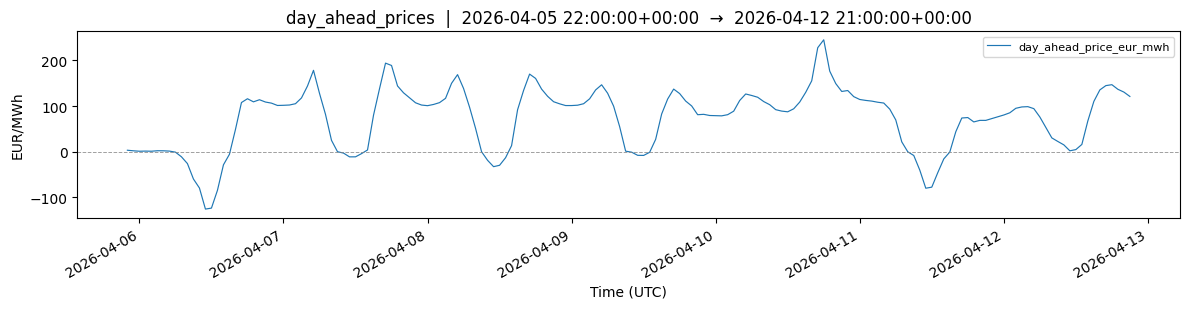

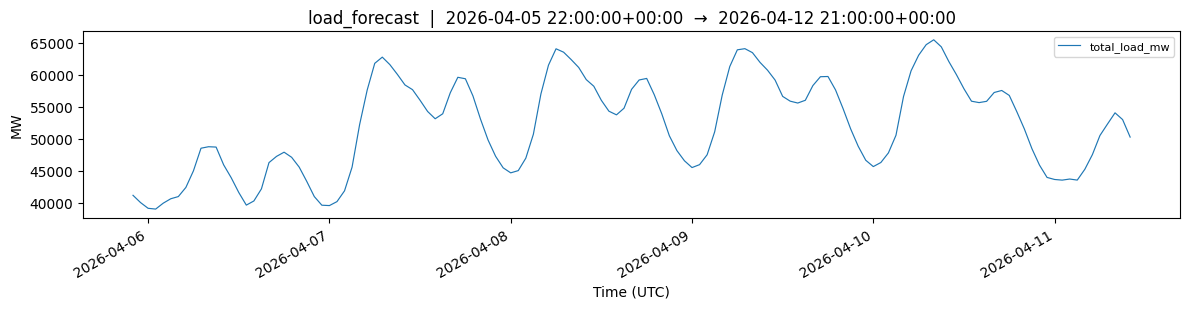

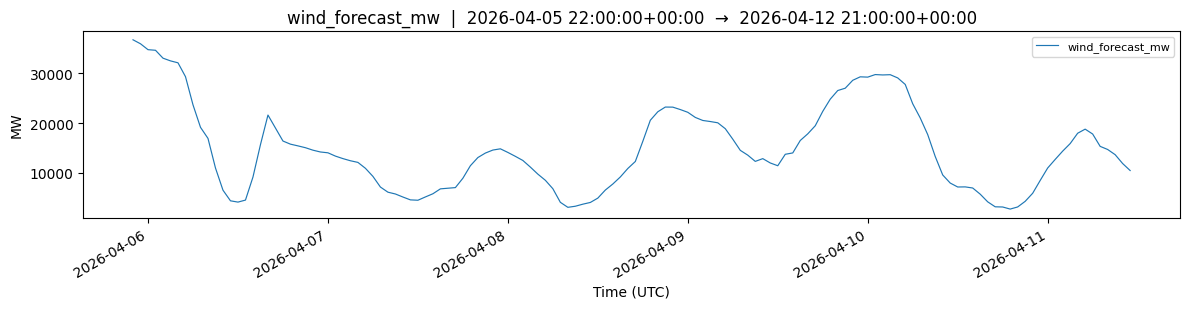

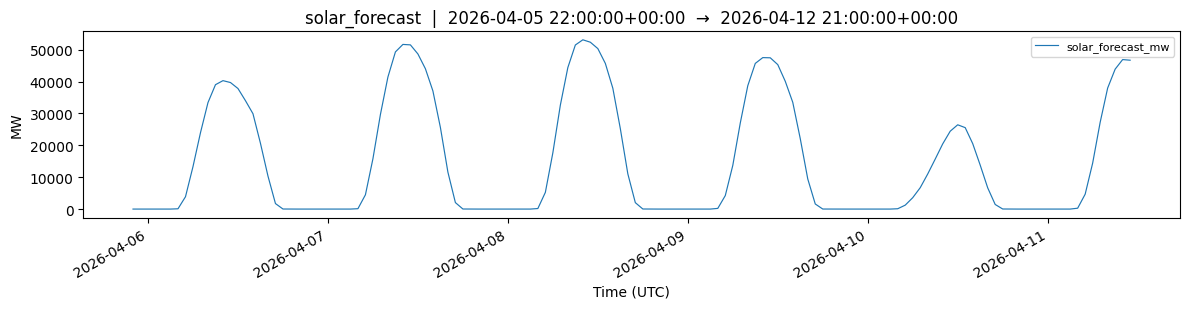

In [3]:
def index_time_bounds(df: pd.DataFrame) -> tuple[object | None, object | None]:
    if df.empty:
        return None, None
    idx = df.index
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.DatetimeIndex(pd.to_datetime(idx, utc=True))
    return idx.min(), idx.max()


coverage_rows: list[dict] = []
for label, path in discover_parquet_datasets(BUNDLE_DIR):
    df = pd.read_parquet(path)
    t0, t1 = index_time_bounds(df)
    coverage_rows.append(
        {
            "dataset": label,
            "start_utc": t0,
            "end_utc": t1,
            "n_rows": len(df),
            "path": str(path.relative_to(REPO_ROOT)),
        }
    )

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

# Y-axis hints (optional labels)
Y_LABELS = {
    "day_ahead_prices": "EUR/MWh",
    "load_forecast": "MW",
    "wind_forecast_mw": "MW (forecast)",
    "solar_forecast": "MW (forecast)",
    "hydro_forecast": "MW (forecast, Sonstige)",
    "wind_generation_actual_mw": "MW (actual)",
    "solar_generation_actual_mw": "MW (actual)",
    "actual_generation_total_mw": "MW",
    "hydro_pumped_storage_generation_mw": "MW",
}

for label, path in discover_parquet_datasets(BUNDLE_DIR):
    df = pd.read_parquet(path).sort_index()
    t0, t1 = index_time_bounds(df)
    if df.empty:
        print(f"{label}: empty parquet, skip plot")
        continue

    numeric = df.select_dtypes(include="number")
    if numeric.empty:
        print(f"{label}: no numeric columns, skip plot")
        continue

    fig, ax = plt.subplots(figsize=(12, 3.2))
    for col in numeric.columns:
        ax.plot(df.index, numeric[col].values, label=str(col), linewidth=0.85)

    short_label = label.split("::")[-1] if "::" in label else label
    y_hint = Y_LABELS.get(short_label, "value")
    ax.set_title(f"{label}  |  {t0}  →  {t1}")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel(y_hint)
    ax.legend(loc="best", fontsize=8)
    if short_label == "day_ahead_prices":
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.7, alpha=0.75)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()